# Exploration

## 1. Imports

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Chargement des données

In [11]:
df = pd.read_csv("../Dataset/GlobalWeatherRepository.csv")

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


## 3. Exploration

In [12]:
df.shape

(126476, 41)

In [13]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='str')

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126476 entries, 0 to 126475
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   country                       126476 non-null  str           
 1   location_name                 126476 non-null  str           
 2   latitude                      126476 non-null  float64       
 3   longitude                     126476 non-null  float64       
 4   timezone                      126476 non-null  str           
 5   last_updated_epoch            126476 non-null  int64         
 6   last_updated                  126476 non-null  datetime64[us]
 7   temperature_celsius           126476 non-null  float64       
 8   temperature_fahrenheit        126476 non-null  float64       
 9   condition_text                126476 non-null  str           
 10  wind_mph                      126476 non-null  float64       
 11  wind_kph                

In [14]:
df.isna().sum().sort_values(ascending=False)

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [15]:
# create a table mapping each column name to its descriptive label
labels = {
    "country": "Country of the weather data",
    "location_name": "Name of the location (city)",
    "latitude": "Latitude coordinate of the location",
    "longitude": "Longitude coordinate of the location",
    "timezone": "Timezone of the location",
    "last_updated_epoch": "Unix timestamp of the last data update",
    "last_updated": "Local time of the last data update",
    "temperature_celsius": "Temperature in degrees Celsius",
    "temperature_fahrenheit": "Temperature in degrees Fahrenheit",
    "condition_text": "Weather condition description",
    "wind_mph": "Wind speed in miles per hour",
    "wind_kph": "Wind speed in kilometers per hour",
    "wind_degree": "Wind direction in degrees",
    "wind_direction": "Wind direction as a 16-point compass",
    "pressure_mb": "Pressure in millibars",
    "pressure_in": "Pressure in inches",
    "precip_mm": "Precipitation amount in millimeters",
    "precip_in": "Precipitation amount in inches",
    "humidity": "Humidity as a percentage",
    "cloud": "Cloud cover as a percentage",
    "feels_like_celsius": "Feels-like temperature in Celsius",
    "feels_like_fahrenheit": "Feels-like temperature in Fahrenheit",
    "visibility_km": "Visibility in kilometers",
    "visibility_miles": "Visibility in miles",
    "uv_index": "UV Index",
    "gust_mph": "Wind gust in miles per hour",
    "gust_kph": "Wind gust in kilometers per hour",
    "air_quality_Carbon_Monoxide": "Air quality measurement: Carbon Monoxide",
    "air_quality_Ozone": "Air quality measurement: Ozone",
    "air_quality_Nitrogen_dioxide": "Air quality measurement: Nitrogen Dioxide",
    "air_quality_Sulphur_dioxide": "Air quality measurement: Sulphur Dioxide",
    "air_quality_PM2.5": "Air quality measurement: PM2.5",
    "air_quality_PM10": "Air quality measurement: PM10",
    "air_quality_us-epa-index": "Air quality measurement: US EPA Index",
    "air_quality_gb-defra-index": "Air quality measurement: GB DEFRA Index",
    "sunrise": "Local time of sunrise",
    "sunset": "Local time of sunset",
    "moonrise": "Local time of moonrise",
    "moonset": "Local time of moonset",
    "moon_phase": "Current moon phase",
    "moon_illumination": "Moon illumination percentage"
}

label_df = pd.DataFrame(list(labels.items()), columns=["column", "label"])
label_df['unique_values'] = label_df['column'].apply(lambda col: df[col].nunique())
label_df['apercu_valeurs_uniques'] = label_df['column'].apply(lambda col: list(df[col].unique()[:5]))
label_df

,column,label,unique_values,apercu_valeurs_uniques
0,country,Country of the weather data,211,"[Afghanistan, Albania, Algeria, Andorra, Angola]"
1,location_name,Name of the location (city),257,"[Kabul, Tirana, Algiers, Andorra La Vella, Lua..."
2,latitude,Latitude coordinate of the location,397,"[34.52, 41.33, 36.76, 42.5, -8.84]"
3,longitude,Longitude coordinate of the location,402,"[69.18, 19.82, 3.05, 1.52, 13.23]"
4,timezone,Timezone of the location,199,"[Asia/Kabul, Europe/Tirane, Africa/Algiers, Eu..."
5,last_updated_epoch,Unix timestamp of the last data update,1195,"[1715849100, 1715868000, 1715868900, 171596160..."
6,last_updated,Local time of the last data update,21266,"[2024-05-16 13:15, 2024-05-16 10:45, 2024-05-1..."
7,temperature_celsius,Temperature in degrees Celsius,704,"[26.6, 19.0, 23.0, 6.3, 26.0]"
8,temperature_fahrenheit,Temperature in degrees Fahrenheit,1166,"[79.8, 66.2, 73.4, 43.3, 78.8]"
9,condition_text,Weather condition description,49,"[Partly Cloudy, Partly cloudy, Sunny, Light dr..."


4 types de variables : 

- Variables géographiques : 

        - country
        - location_name
        - latitude
        - longitude
        - timezone

- Variables météo : 

        - temperature (C/F)
        - humidity
        - pressure
        - wind
        - precipitation
        - cloud
        - visibility
        - uv_index
        - sunrise/sunset
        - moon_phase
        - ...

- Polluants : 

        - CO
        - Ozone
        - NO2
        - SO2
        - PM2.5
        - PM10
        - US EPA Index
        - GB DEFRA Index

- Dimension temporelle : 

        - last_updated
        - last_updated_epoch

Les deux colonnes suivantes codent un indice qualitatif de pollution atmosphérique :

- **`air_quality_us-epa-index`** : mesure de la qualité de l’air selon l’échelle de l’US EPA (United States Environmental Protection Agency).  Les valeurs vont de 1 à 6, correspondant à des catégories allant de "Good" à "Hazardous".
- **`air_quality_gb-defra-index`** : mesure équivalente selon l’échelle britannique DEFRA.  Les valeurs se situent entre 1 et 10, un numéro plus élevé indiquant une mauvaise qualité de l’air.

Ci-dessous, on construit deux petits DataFrame donnant pour chaque valeur unique le libellé associé.

In [33]:
# build lookup tables for the two indices
us_categories = sorted(df['air_quality_us-epa-index'].dropna().unique())
us_map = {
    1: 'Good',
    2: 'Moderate',
    3: 'Unhealthy for Sensitive Groups',
    4: 'Unhealthy',
    5: 'Very Unhealthy',
    6: 'Hazardous'
}
us_df = pd.DataFrame({'value': us_categories,
                      'label': [us_map.get(int(v), f'Category {int(v)}') for v in us_categories]})

# DEFRA index uses bands: 1-3 low, 4-6 moderate, 7-9 high, 10 very high
gb_map = {**{i: 'Low' for i in range(1,4)},
          **{i: 'Moderate' for i in range(4,7)},
          **{i: 'High' for i in range(7,10)},
          10: 'Very High'}
gb_categories = sorted(df['air_quality_gb-defra-index'].dropna().unique())
gb_df = pd.DataFrame({
    'value': gb_categories,
    'label': [gb_map.get(int(v), f'Level {int(v)}') for v in gb_categories]
})

In [34]:
us_df

,value,label
0,1,Good
1,2,Moderate
2,3,Unhealthy for Sensitive Groups
3,4,Unhealthy
4,5,Very Unhealthy
5,6,Hazardous


In [35]:
gb_df

,value,label
0,1,Low
1,2,Low
2,3,Low
3,4,Moderate
4,5,Moderate
5,6,Moderate
6,7,High
7,8,High
8,9,High
9,10,Very High


In [59]:
df['timezone'].head(20)

0                         Asia/Kabul
1                      Europe/Tirane
2                     Africa/Algiers
3                     Europe/Andorra
4                      Africa/Luanda
5                    America/Antigua
6     America/Argentina/Buenos_Aires
7                       Asia/Yerevan
8                   Australia/Sydney
9                      Europe/Vienna
10                         Asia/Baku
11                    America/Nassau
12                      Asia/Bahrain
13                        Asia/Dhaka
14                  America/Barbados
15                      Europe/Minsk
16                   Europe/Brussels
17                    America/Belize
18                 Africa/Porto-Novo
19                      Asia/Thimphu
Name: timezone, dtype: str

## 4. Visualisation

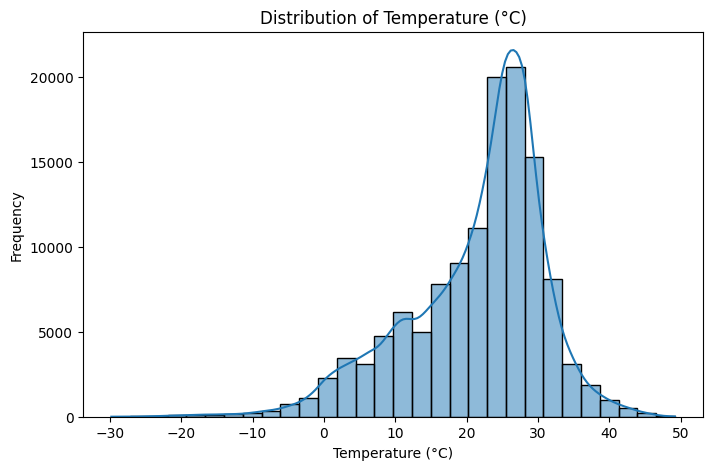

In [20]:
# 1. Histogram of temperature
plt.figure(figsize=(8,5))
sns.histplot(df['temperature_celsius'].dropna(), kde=True, bins=30)
plt.title('Distribution of Temperature (°C)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()


C:\Users\LéaGravellard\AppData\Local\Temp\ipykernel_29228\578919410.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




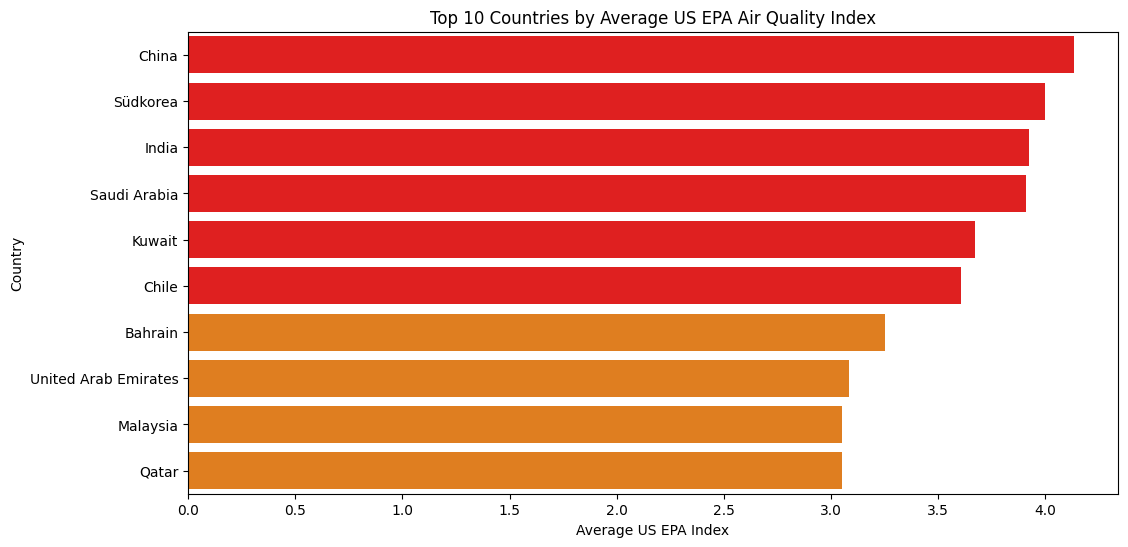

In [55]:
# 2. Bar chart of average pollution index by country (top 10)
pollution_by_country = (
    df.dropna(subset=['country', 'air_quality_us-epa-index'])
      .groupby('country')['air_quality_us-epa-index']
      .mean()
      .sort_values(ascending=False)
)

# Map average EPA index to colors
epa_colors_map = {
    1: '#00e400',  # green
    2: '#ffff00',  # yellow
    3: '#ff7e00',  # orange
    4: '#ff0000',  # red
    5: '#8f3f97',  # purple/violet
    6: '#7e0023'   # dark red/maroon
}

bar_colors = [epa_colors_map.get(int(round(val)), '#999999') for val in pollution_by_country.head(10).values]

plt.figure(figsize=(12,6))
sns.barplot(x=pollution_by_country.head(10).values, y=pollution_by_country.head(10).index, palette='Reds')
plt.title('Top 10 Countries by Average US EPA Air Quality Index')
plt.xlabel('Average US EPA Index')
plt.ylabel('Country')
plt.show()

C:\Users\LéaGravellard\AppData\Local\Temp\ipykernel_29228\2653926297.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='air_quality_us-epa-index', palette=epa_colors)


C:\Users\LéaGravellard\AppData\Local\Temp\ipykernel_29228\2653926297.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='air_quality_us-epa-index', palette=epa_colors)


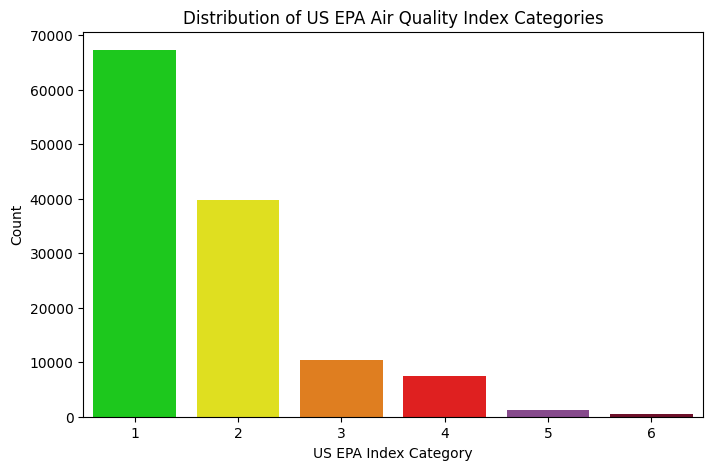

In [39]:
# 3. Distribution of air quality categories (US EPA index)
plt.figure(figsize=(8,5))
# define colors matching US EPA AQI categories
epa_colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']
sns.countplot(data=df, x='air_quality_us-epa-index', palette=epa_colors)
plt.title('Distribution of US EPA Air Quality Index Categories')
plt.xlabel('US EPA Index Category')
plt.ylabel('Count')
plt.show()

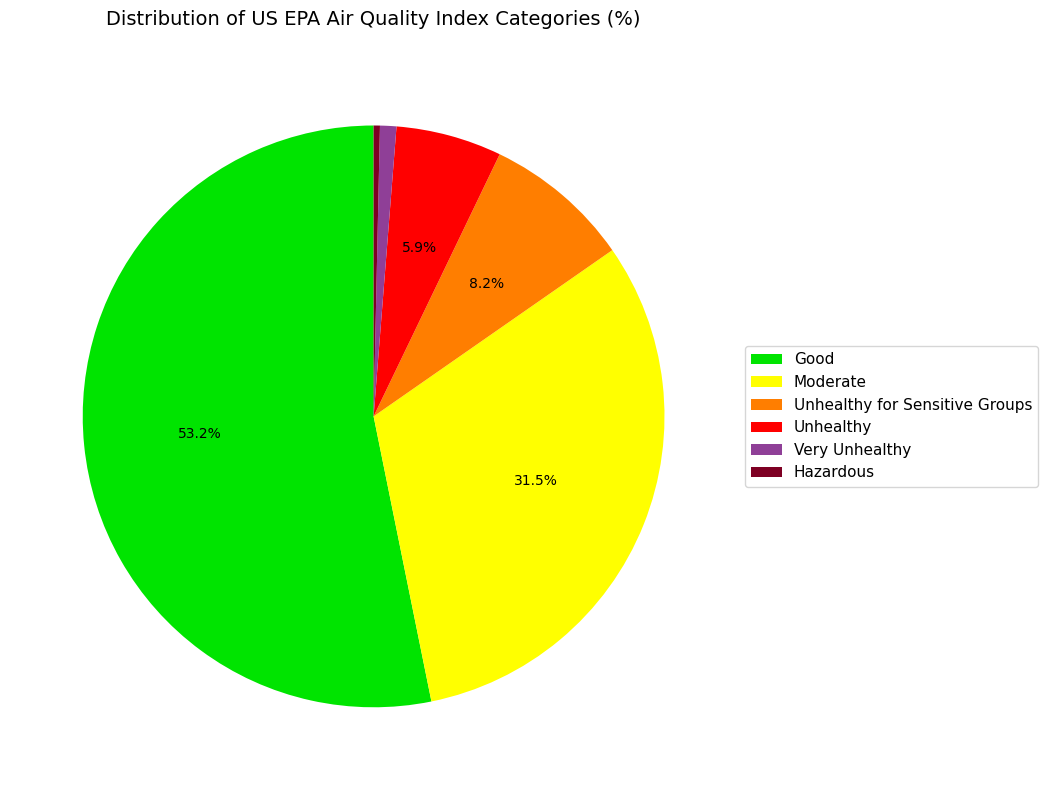

In [52]:
# 4. Pie chart of US EPA air quality index distribution
epa_labels = {1: 'Good', 2: 'Moderate', 3: 'Unhealthy for Sensitive Groups', 
              4: 'Unhealthy', 5: 'Very Unhealthy', 6: 'Hazardous'}
epa_counts = df['air_quality_us-epa-index'].value_counts().sort_index()
epa_colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']

def autopct_format(pct):
    return f'{pct:.1f}%' if pct >= 2 else ''

plt.figure(figsize=(12,8))
plt.pie(
    epa_counts.values,
    autopct=autopct_format,
    colors=epa_colors,
    startangle=90
)
plt.title('Distribution of US EPA Air Quality Index Categories (%)', fontsize=14, pad=20)
plt.legend(
    [epa_labels.get(int(i), f'Category {i}') for i in epa_counts.index], 
    loc='center left',
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)
plt.tight_layout()
plt.show()

C:\Users\LéaGravellard\AppData\Local\Temp\ipykernel_29228\2640937959.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




C:\Users\LéaGravellard\AppData\Local\Temp\ipykernel_29228\2640937959.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




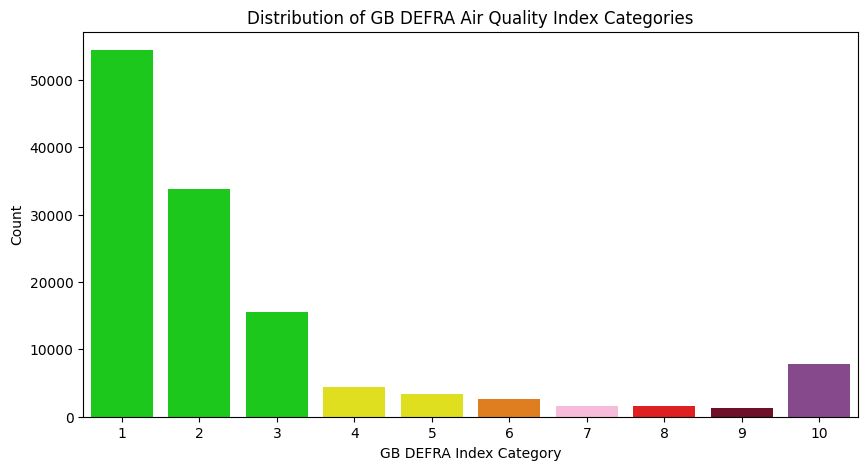

In [53]:
# 3b. Distribution of air quality categories (GB DEFRA index)
plt.figure(figsize=(10,5))
# define colors matching GB DEFRA AQI categories (1-10)
defra_colors = ['#00e400', '#00e400', '#00e400', '#ffff00', '#ffff00', '#ff7e00', '#ffb3d9', '#ff0000', '#7e0023', '#8f3f97']
sns.countplot(data=df, x='air_quality_gb-defra-index', palette=defra_colors)
plt.title('Distribution of GB DEFRA Air Quality Index Categories')
plt.xlabel('GB DEFRA Index Category')
plt.ylabel('Count')
plt.show()

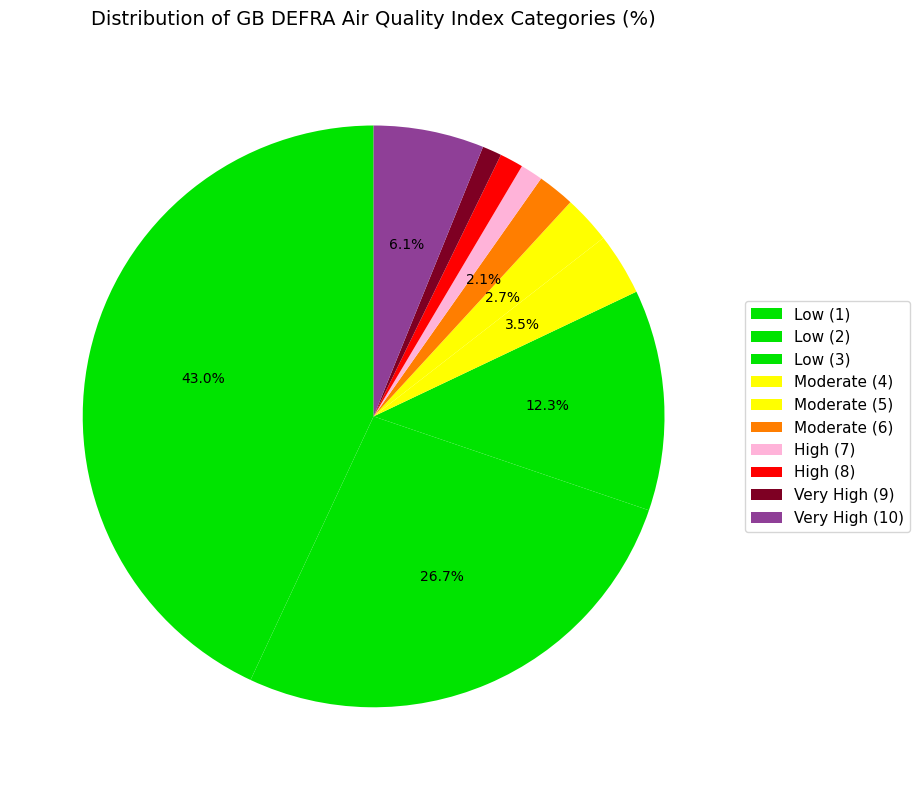

In [ ]:
# 5. Pie chart of GB DEFRA air quality index distribution
gb_labels = {1: 'Low (1)', 2: 'Low (2)', 3: 'Low (3)', 4: 'Moderate (4)', 5: 'Moderate (5)', 
             6: 'Moderate (6)', 7: 'High (7)', 8: 'High (8)', 9: 'Very High (9)', 10: 'Very High (10)'}
gb_counts = df['air_quality_gb-defra-index'].value_counts().sort_index()
gb_colors_dict = {1: '#00e400', 2: '#00e400', 3: '#00e400', 4: '#ffff00', 5: '#ffff00', 
                  6: '#ff7e00', 7: '#ffb3d9', 8: '#ff0000', 9: '#7e0023', 10: '#8f3f97'}

def autopct_format(pct):
    return f'{pct:.1f}%' if pct >= 2 else ''

plt.figure(figsize=(12,8))
plt.pie(
    gb_counts.values,
    autopct=autopct_format,
    colors=[gb_colors_dict.get(int(i), '#999999') for i in gb_counts.index],
    startangle=90
)
plt.title('Distribution of GB DEFRA Air Quality Index Categories (%)', fontsize=14, pad=20)
plt.legend(
    [gb_labels.get(int(i), f'Level {i}') for i in gb_counts.index], 
    loc='center left',
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)
plt.tight_layout()
plt.show()

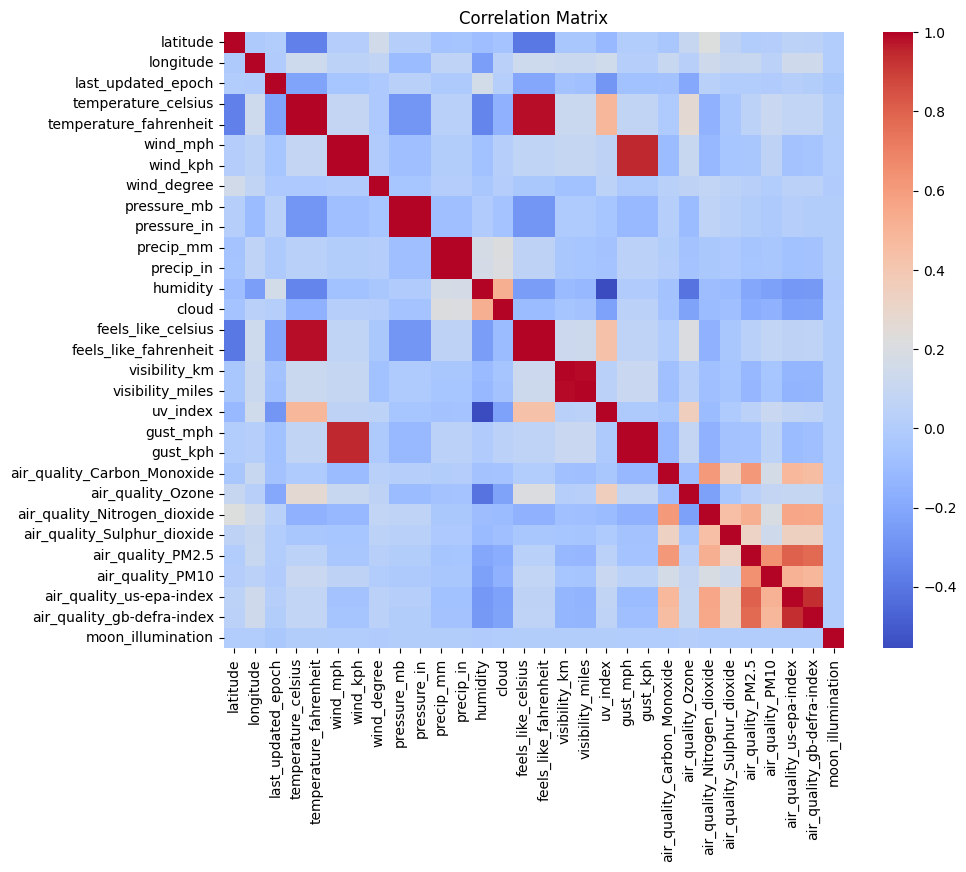

In [60]:
# 5. Correlation matrix of numerical features

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()